# Exploratory Data Analysis — Job Market & User CV
---


**Business Questions:**
1. Pekerjaan apa yang memiliki tingkat kecocokan tertinggi dengan pengalaman user?
2. Keterampilan inti apa yang belum dimiliki user namun krusial untuk posisi target?
3. Apa 3–5 pekerjaan teratas yang paling cocok beserta persentase kecocokannya?

---

## Setup & Import Library

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#7b5ea7','#a78bfa','#60a5fa','#34d399','#f472b6',
           '#fb923c','#facc15','#38bdf8','#a3e635','#f87171']


## Bagian I : Load & Inspeksi Dataset

In [3]:
jm = pd.read_csv('JobMarket_Preprocessed.csv')
cv = pd.read_csv('cv_processed.csv')

print(f"JobMarket  : {jm.shape[0]:,} baris × {jm.shape[1]} kolom")
print(f"CV / Users : {cv.shape[0]:,} baris × {cv.shape[1]} kolom")
print()
print("── Kolom JobMarket ──")
print(jm.dtypes.to_string())
print()
print("── Kolom CV ──")
print(cv.dtypes.to_string())

JobMarket  : 1,000 baris × 8 kolom
CV / Users : 1,000 baris × 11 kolom

── Kolom JobMarket ──
job_id                         object
job_title                      object
extracted_skills               object
experience_level               object
extracted_job_skills_count      int64
role_category                  object
extracted_requirements         object
extracted_responsibilities    float64

── Kolom CV ──
Unnamed: 0                      int64
user_id                        object
name                           object
last_role                      object
raw_cv_text                    object
extracted_user_skills          object
education                      object
major                          object
extracted_skills_structured    object
projects                       object
experience                     object


In [4]:
print("=== Sample JobMarket ===")
display(jm.head(3))
print("\n=== Sample CV ===")
display(cv.head(3))

=== Sample JobMarket ===


,job_id,job_title,extracted_skills,experience_level,extracted_job_skills_count,role_category,extracted_requirements,extracted_responsibilities
0,dcedd22a-ecbf-402c-b657-570885b37fb3,it recruiter,"scrum, problem solving, strategic planning, ag...",senior level,5,hr / recruiter,teknis wajib menguasai scrum problem solving s...,NaN
1,302bcf5b-303e-4501-9b38-7b0eda40366a,data analyst,"scikit-learn, data visualization, scrum, agile...",NaN,5,data analyst,teknis wajib menguasai scikitlearn data visual...,NaN
2,fb99ecb9-f527-4116-aea8-89c9b86cf1f7,product manager,"scrum, leadership, strategic planning, agile, ...",NaN,5,product manager,teknis wajib menguasai scrum leadership strate...,NaN



=== Sample CV ===


,Unnamed: 0,user_id,name,last_role,raw_cv_text,extracted_user_skills,education,major,extracted_skills_structured,projects,experience
0,0,4053a618-a3ad-48a8-bc47-60f2b78f23a9,Rian Setiawan,ui designer magang,curriculum vitae ringkas nama rian setiawan ko...,figma user research uiux prototyping kreativitas,not specified,other,unspecified,not specified,not specified
1,1,6cbc999b-c041-4015-bf6f-dea1ec3249c4,Fikran Setiawan,ketua bem,curriculum vitae ringkas nama fikran setiawan ...,leadership microsoft office manajemen waktu ko...,not specified,other,agile,not specified,terapkan meliputi leadership microsoft office ...
2,2,e52de38f-bf7b-4567-9217-78bf54964452,Rina Siregar,asisten laboratorium komputer,curriculum vitae ringkas nama rina siregar kon...,postgresql problem solving htmlcss,not specified,other,"postgresql, cloud",not specified,not specified


In [5]:
print("=== Missing Values — JobMarket ===")
display(jm.isnull().sum().to_frame('missing').assign(pct=lambda d: (d['missing']/len(jm)*100).round(2)))
print("\n=== Missing Values — CV ===")
display(cv.isnull().sum().to_frame('missing').assign(pct=lambda d: (d['missing']/len(cv)*100).round(2)))

=== Missing Values — JobMarket ===


,missing,pct
job_id,0,0.0
job_title,0,0.0
extracted_skills,0,0.0
experience_level,484,48.4
extracted_job_skills_count,0,0.0
role_category,0,0.0
extracted_requirements,0,0.0
extracted_responsibilities,1000,100.0



=== Missing Values — CV ===


,missing,pct
Unnamed: 0,0,0.0
user_id,0,0.0
name,0,0.0
last_role,0,0.0
raw_cv_text,0,0.0
extracted_user_skills,0,0.0
education,0,0.0
major,0,0.0
extracted_skills_structured,0,0.0
projects,0,0.0


## EDA Umum

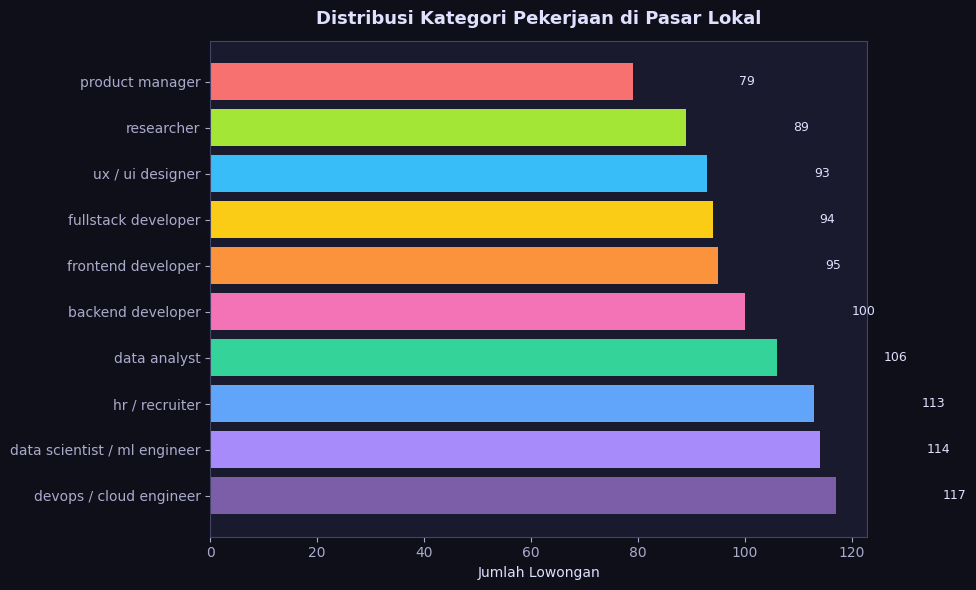

In [9]:
# Distribusi role_category di JobMarket
role_counts = jm['role_category'].value_counts()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    role_counts.index,
    role_counts.values,
    color=PALETTE[:len(role_counts)]
)

plt.title(
    'Distribusi Kategori Pekerjaan di Pasar Lokal',
    fontsize=13,
    fontweight='bold',
    pad=12
)
plt.xlabel('Jumlah Lowongan')

for bar, val in zip(bars, role_counts.values):
    plt.text(
        val + 20,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('plot_role_distribution_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# print(role_counts.to_string())

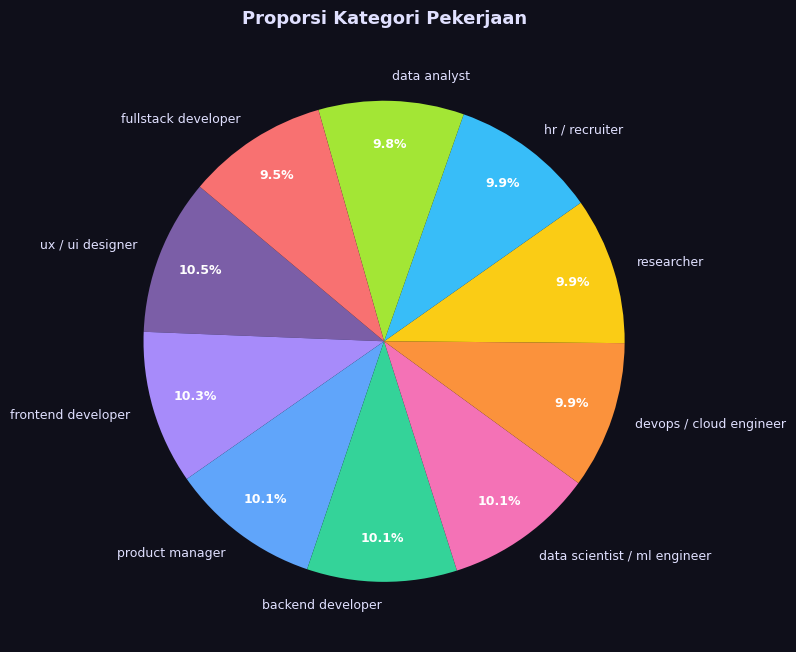

In [ ]:
# Pie Chart Proporsi Kategori Pekerjaan

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    role_counts.values,
    labels=role_counts.index,
    colors=PALETTE[:len(role_counts)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    textprops={'fontsize': 9}
)

plt.title(
    'Proporsi Kategori Pekerjaan',
    fontsize=13,
    fontweight='bold',
    pad=12
)

for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')

plt.tight_layout()
plt.savefig('plot_role_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

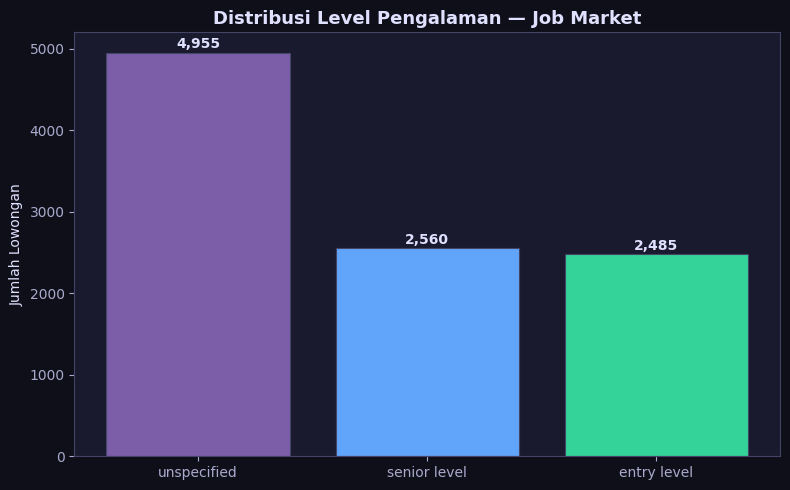

In [ ]:
# Distribusi experience level
exp_counts = jm['experience_level'].fillna('unspecified').value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#0f0f1a')
bars = ax.bar(exp_counts.index, exp_counts.values,
              color=['#7b5ea7','#60a5fa','#34d399'], edgecolor='#444466', linewidth=0.8)
ax.set_title('Distribusi Level Pengalaman — Job Market', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Lowongan')
for bar, val in zip(bars, exp_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold', color='#e0e0ff')
plt.tight_layout()
plt.savefig('plot_exp_level.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

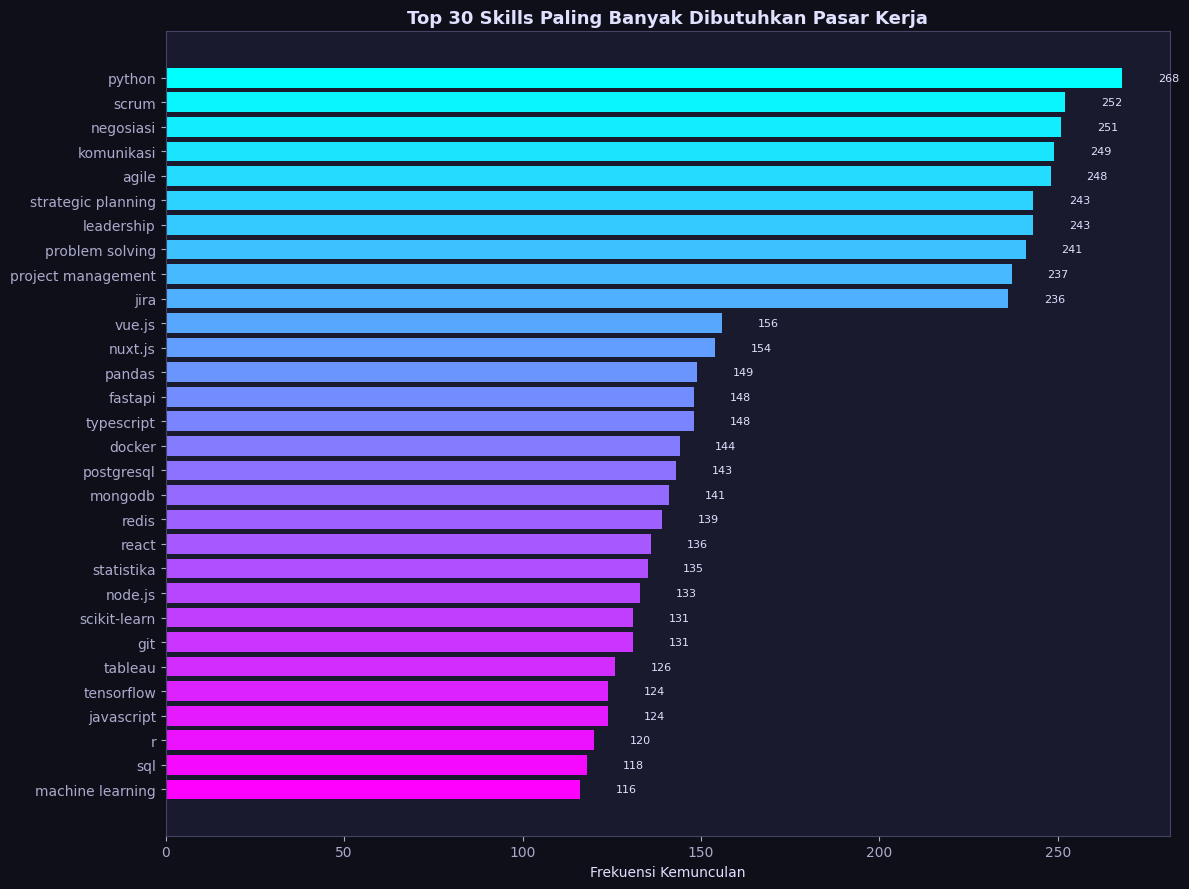

In [10]:
# Top 30 skills paling banyak dicari di pasar kerja
def parse_skills(series):
    all_skills = []
    for s in series.dropna():
        skills = [x.strip().lower() for x in str(s).split(',') if x.strip()]
        all_skills.extend(skills)
    return Counter(all_skills)

jm_skill_counts = parse_skills(jm['extracted_skills'])
top30_jm = pd.DataFrame(jm_skill_counts.most_common(30), columns=['skill','count'])

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#0f0f1a')
cmap = plt.cm.get_cmap('cool', 30)
colors = [cmap(i/30) for i in range(30)]
bars = ax.barh(top30_jm['skill'], top30_jm['count'], color=colors)
ax.set_title('Top 30 Skills Paling Banyak Dibutuhkan Pasar Kerja', fontsize=13, fontweight='bold')
ax.set_xlabel('Frekuensi Kemunculan')
ax.invert_yaxis()
for bar, val in zip(bars, top30_jm['count']):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8, color='#e0e0ff')
plt.tight_layout()
plt.savefig('plot_top30_jm_skills.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
# display(top30_jm)

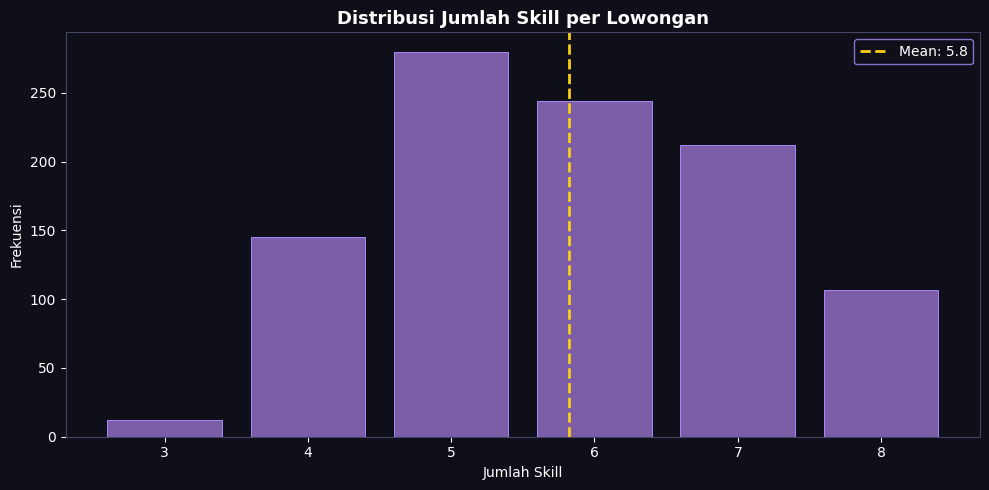

count    1000.000000
mean        5.820000
std         1.255857
min         3.000000
25%         5.000000
50%         6.000000
75%         7.000000
max         8.000000
Name: extracted_job_skills_count, dtype: float64


In [13]:
# Distribusi jumlah skill per lowongan
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a') # Memastikan background dalam juga gelap

# 1. Ambil nilai min dan max dari data bulat Anda
data_clean = jm['extracted_job_skills_count'].dropna()
min_val = int(data_clean.min())
max_val = int(data_clean.max())

# 2. Buat batas bin kustom di antara angka bulat (misal: 2.5, 3.5, 4.5, ... dst)
# Ini akan membuat angka bulat berada tepat di TENGAH bin
bins_custom = np.arange(min_val - 0.5, max_val + 1.5, 1)

# 3. Plot histogram dengan rwidth agar ada jarak estetis antar batang
ax.hist(data_clean, bins=bins_custom, color='#7b5ea7',
        edgecolor='#a78bfa', linewidth=0.7, rwidth=0.8)

# 4. Pasang xticks tepat di angka bulatnya
ax.set_xticks(np.arange(min_val, max_val + 1))

# 5. Atur warna text sumbu agar terlihat di background gelap
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

# Garis Mean
ax.axvline(data_clean.mean(), color='#facc15', linestyle='--',
           linewidth=2, label=f"Mean: {data_clean.mean():.1f}")

ax.set_title('Distribusi Jumlah Skill per Lowongan', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Skill')
ax.set_ylabel('Frekuensi')

# Atur text legend agar putih
legend = ax.legend(facecolor='#0f0f1a', edgecolor='#a78bfa')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig('plot_skill_count_dist.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print(jm['extracted_job_skills_count'].describe())

## **Business Question 1**
Pekerjaan apa di pasar tenaga kerja lokal yang memiliki tingkat kecocokan tertinggi dengan pengalaman formal maupun non-formal dari users saat ini?

**Pendekatan:**
- Hitung *match score* tiap user terhadap setiap `role_category` di job market
- Match score = (jumlah skill user yang ada di skill pool role itu) / (total unique skill yang dibutuhkan role)
- Agregat per role → rata-rata match score seluruh user


In [15]:
# ── Bangun skill pool per role_category ──────────────────────────────────────
role_skill_pool = {}
for role, grp in jm.groupby('role_category'):
    skills = set()
    for s in grp['extracted_skills'].dropna():
        skills.update([x.strip().lower() for x in str(s).split(',') if x.strip()])
    role_skill_pool[role] = skills

print("Skill pool per role (contoh 3):")
for r, sp in list(role_skill_pool.items())[:3]:
    print(f"  {r}: {len(sp)} unique skills → {list(sp)[:5]} ...")

Skill pool per role (contoh 3):
  backend developer: 22 unique skills → ['docker', 'react', 'mongodb', 'strategic planning', 'python'] ...
  data analyst: 20 unique skills → ['tensorflow', 'sql', 'strategic planning', 'statistika', 'python'] ...
  data scientist / ml engineer: 20 unique skills → ['tensorflow', 'sql', 'strategic planning', 'statistika', 'python'] ...


In [16]:
# ── Hitung match score setiap user per role ──────────────────────────────────
def user_skills_set(row):
    skills = set()
    for col in ['extracted_user_skills', 'extracted_skills_structured']:
        val = row.get(col, '')
        if pd.notna(val) and str(val).strip() not in ('', 'unspecified', 'not specified'):
            skills.update([x.strip().lower() for x in str(val).split(',') if x.strip()])
    return skills

roles = list(role_skill_pool.keys())
records = []
for _, user in cv.iterrows():
    uset = user_skills_set(user)
    for role in roles:
        pool = role_skill_pool[role]
        matched = len(uset & pool)
        score = matched / len(pool) if len(pool) > 0 else 0
        records.append({'user_id': user['user_id'], 'role': role,
                        'match_score': score, 'matched_skills': matched,
                        'pool_size': len(pool)})

match_df = pd.DataFrame(records)
print(f"Total kombinasi user-role: {len(match_df):,}")
display(match_df.head(8))

Total kombinasi user-role: 10,000


,user_id,role,match_score,matched_skills,pool_size
0,4053a618-a3ad-48a8-bc47-60f2b78f23a9,backend developer,0.0,0,22
1,4053a618-a3ad-48a8-bc47-60f2b78f23a9,data analyst,0.0,0,20
2,4053a618-a3ad-48a8-bc47-60f2b78f23a9,data scientist / ml engineer,0.0,0,20
3,4053a618-a3ad-48a8-bc47-60f2b78f23a9,devops / cloud engineer,0.0,0,22
4,4053a618-a3ad-48a8-bc47-60f2b78f23a9,frontend developer,0.0,0,22
5,4053a618-a3ad-48a8-bc47-60f2b78f23a9,fullstack developer,0.0,0,22
6,4053a618-a3ad-48a8-bc47-60f2b78f23a9,hr / recruiter,0.0,0,9
7,4053a618-a3ad-48a8-bc47-60f2b78f23a9,product manager,0.0,0,9


In [17]:
# ── Rata-rata match score per role (semua user) ───────────────────────────────
avg_match = (match_df.groupby('role')['match_score']
             .agg(['mean','median','std'])
             .round(4)
             .sort_values('mean', ascending=False)
             .reset_index())
avg_match.columns = ['role_category','avg_match_score','median_score','std_score']
avg_match['avg_match_pct'] = (avg_match['avg_match_score']*100).round(2)

print("Rata-rata kecocokan user dengan tiap role:")
display(avg_match)

Rata-rata kecocokan user dengan tiap role:


,role_category,avg_match_score,median_score,std_score,avg_match_pct
0,backend developer,0.0418,0.0455,0.0459,4.18
1,devops / cloud engineer,0.0418,0.0455,0.0459,4.18
2,fullstack developer,0.0418,0.0455,0.0459,4.18
3,frontend developer,0.0418,0.0455,0.0459,4.18
4,data analyst,0.0385,0.0500,0.0413,3.85
5,data scientist / ml engineer,0.0385,0.0500,0.0413,3.85
6,researcher,0.0385,0.0500,0.0413,3.85
7,hr / recruiter,0.0171,0.0000,0.0401,1.71
8,product manager,0.0171,0.0000,0.0401,1.71
9,ux / ui designer,0.0091,0.0000,0.0212,0.91


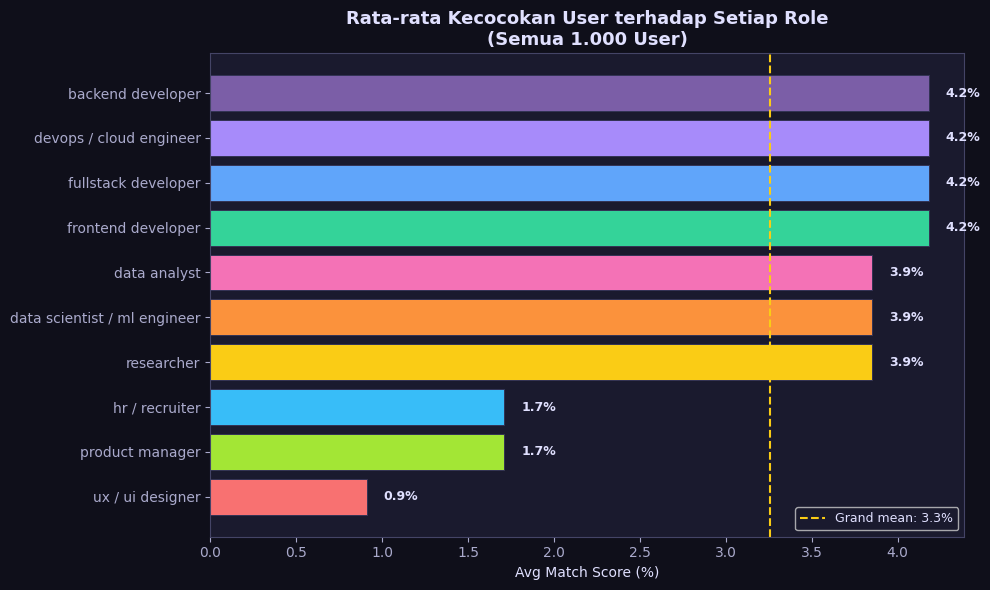

In [18]:
plt.figure(figsize=(10, 6))

colors_bar = [PALETTE[i] for i in range(len(avg_match))]

bars = plt.barh(
    avg_match['role_category'],
    avg_match['avg_match_pct'],
    color=colors_bar,
    edgecolor='#333355',
    linewidth=0.7
)

grand_mean = avg_match['avg_match_pct'].mean()

plt.title(
    'Rata-rata Kecocokan User terhadap Setiap Role\n(Semua 1.000 User)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Avg Match Score (%)')

plt.axvline(
    grand_mean,
    color='#facc15',
    linestyle='--',
    linewidth=1.5,
    label=f'Grand mean: {grand_mean:.1f}%'
)

plt.legend(fontsize=9)
plt.gca().invert_yaxis()

for bar, val in zip(bars, avg_match['avg_match_pct']):
    plt.text(
        val + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('plot_bq1_avg_match_score.png', dpi=150, bbox_inches='tight')
plt.show()

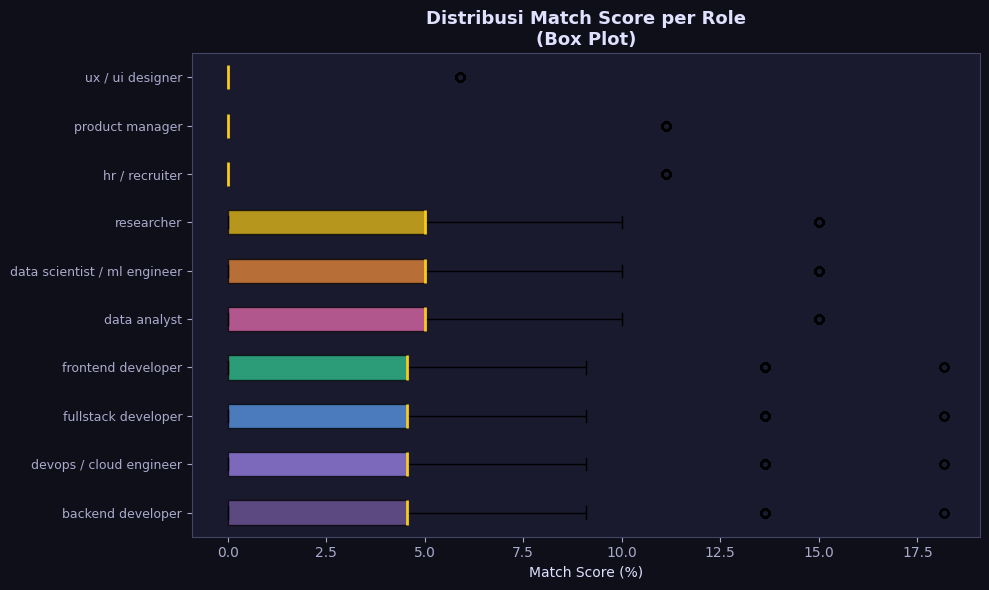

In [19]:
plt.figure(figsize=(10, 6))

role_order = avg_match['role_category'].tolist()
data_box = [
    match_df[match_df['role'] == r]['match_score'] * 100
    for r in role_order
]

bp = plt.boxplot(
    data_box,
    vert=False,
    patch_artist=True,
    medianprops=dict(
        color='#facc15',
        linewidth=2
    )
)

colors_bar = [PALETTE[i] for i in range(len(role_order))]

for patch, color in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.yticks(
    range(1, len(role_order) + 1),
    role_order,
    fontsize=9
)

plt.title(
    'Distribusi Match Score per Role\n(Box Plot)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Match Score (%)')

plt.tight_layout()
plt.savefig('plot_bq1_match_score_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

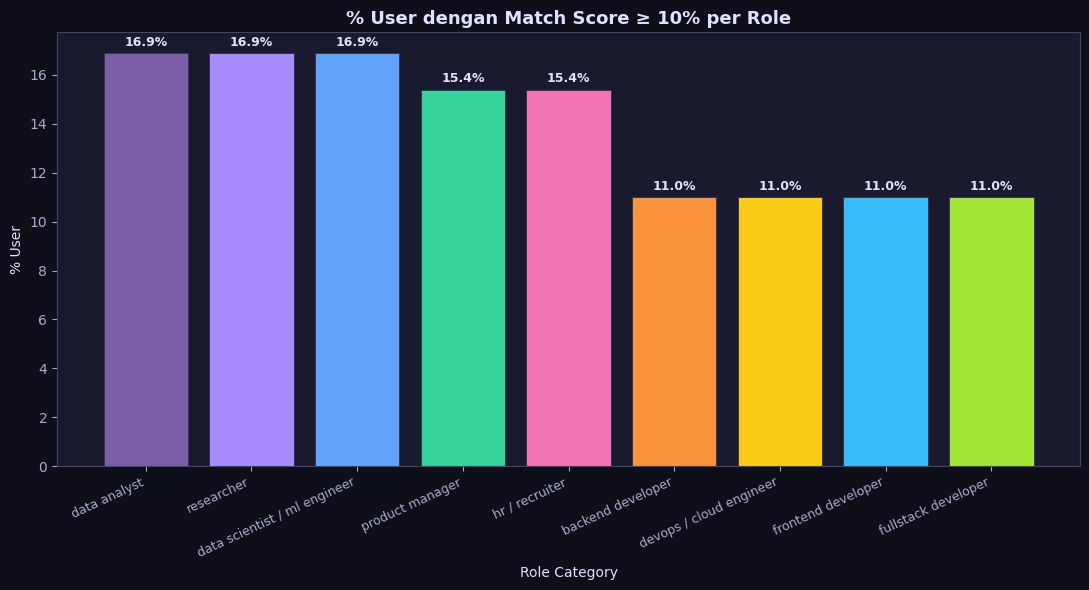

,role_category,users_above_30pct,pct_of_users
0,data analyst,169,16.9
1,researcher,169,16.9
2,data scientist / ml engineer,169,16.9
3,product manager,154,15.4
4,hr / recruiter,154,15.4
5,backend developer,110,11.0
6,devops / cloud engineer,110,11.0
7,frontend developer,110,11.0
8,fullstack developer,110,11.0


In [20]:
# ── Top role berdasarkan jumlah user yang memiliki ≥ 10% match ───────────────
threshold = 0.10
top_roles = (match_df[match_df['match_score'] >= threshold]
             .groupby('role')['user_id']
             .count()
             .sort_values(ascending=False)
             .reset_index())
top_roles.columns = ['role_category','users_above_30pct']
top_roles['pct_of_users'] = (top_roles['users_above_30pct'] / cv.shape[0] * 100).round(2)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0f0f1a')
bars = ax.bar(top_roles['role_category'], top_roles['pct_of_users'],
              color=[PALETTE[i] for i in range(len(top_roles))],
              edgecolor='#333355', linewidth=0.7)
ax.set_title('% User dengan Match Score ≥ 10% per Role', fontsize=13, fontweight='bold')
ax.set_ylabel('% User'); ax.set_xlabel('Role Category')
plt.xticks(rotation=25, ha='right', fontsize=9)
for bar, val in zip(bars, top_roles['pct_of_users']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold', color='#e0e0ff')
plt.tight_layout()
plt.savefig('plot_bq1_users_above_threshold.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
display(top_roles)

In [21]:
best_role = avg_match.iloc[0]
print("=" * 60)
print("JAWABAN BUSINESS QUESTION 1")
print("=" * 60)
print(f"Role dengan kecocokan TERTINGGI:")
print(f"   → {best_role['role_category'].upper()}")
print(f"   Avg Match Score : {best_role['avg_match_pct']:.2f}%")
print(f"   Median Score    : {best_role['median_score']*100:.2f}%")
print()
print("Ranking lengkap:")
for _, row in avg_match.iterrows():
    print(f"  {row['role_category']:35s} {row['avg_match_pct']:5.2f}%")
print("=" * 60)

JAWABAN BUSINESS QUESTION 1
Role dengan kecocokan TERTINGGI:
   → BACKEND DEVELOPER
   Avg Match Score : 4.18%
   Median Score    : 4.55%

Ranking lengkap:
  backend developer                    4.18%
  devops / cloud engineer              4.18%
  fullstack developer                  4.18%
  frontend developer                   4.18%
  data analyst                         3.85%
  data scientist / ml engineer         3.85%
  researcher                           3.85%
  hr / recruiter                       1.71%
  product manager                      1.71%
  ux / ui designer                     0.91%



## **Business Question 2**
Apa saja keterampilan inti yang saat ini tidak dimiliki oleh users, namun paling krusial untuk dipelajari agar bisa diterima di posisi yang ditargetkan?

**Pendekatan:**
- Tentukan "posisi target" = role dengan rata-rata match score tertinggi (BQ1)
- Ambil semua skill yang dibutuhkan role tersebut (skill pool)
- Hitung *gap skill* = skill yang ada di pool tapi tidak dimiliki mayoritas user
- Ranking berdasarkan frekuensi kemunculan di job posting (proxy "krusialitas")


In [24]:
# ── Ambil posisi target = role #1 dari BQ1 ───────────────────────────────────
target_role = avg_match.iloc[0]['role_category']
print(f"Posisi Target: {target_role}")

# Skill pool target role
target_pool = role_skill_pool[target_role]
print(f"   Total skill dibutuhkan: {len(target_pool)}")
print(f"   Contoh skill: {list(target_pool)[:10]}")

Posisi Target: backend developer
   Total skill dibutuhkan: 22
   Contoh skill: ['docker', 'react', 'mongodb', 'strategic planning', 'python', 'komunikasi', 'javascript', 'agile', 'nuxt.js', 'problem solving']


In [26]:
# ── Hitung skill gap tiap user terhadap target role ──────────────────────────
def parse_skills(series):
    all_skills = []
    for s in series.dropna():
        skills = [x.strip().lower() for x in str(s).split(',') if x.strip()]
        all_skills.extend(skills)
    return Counter(all_skills)

gap_records = []
for _, user in cv.iterrows():
    uset = user_skills_set(user)
    gap = target_pool - uset
    gap_records.append({'user_id': user['user_id'], 'gap_skills': gap})

gap_counter = Counter()
for r in gap_records:
    gap_counter.update(r['gap_skills'])

gap_df = pd.DataFrame(gap_counter.most_common(), columns=['skill','users_missing'])
gap_df['pct_users_missing'] = (gap_df['users_missing'] / cv.shape[0] * 100).round(2)

jm_target = jm[jm['role_category'] == target_role]
target_skill_freq = parse_skills(jm_target['extracted_skills'])
gap_df['job_freq'] = gap_df['skill'].map(lambda s: target_skill_freq.get(s, 0))

gap_df['crucial_score'] = (gap_df['pct_users_missing']/100 * 0.5 +
                            gap_df['job_freq'] / (gap_df['job_freq'].max() + 1e-9) * 0.5)
gap_df = gap_df.sort_values('crucial_score', ascending=False).reset_index(drop=True)

print(f"Total skill gap unik: {len(gap_df)}")
display(gap_df.head(20))

Total skill gap unik: 22


,skill,users_missing,pct_users_missing,job_freq,crucial_score
0,docker,1000,100.0,40,1.0000
1,vue.js,1000,100.0,39,0.9875
2,mongodb,1000,100.0,39,0.9875
3,fastapi,1000,100.0,37,0.9625
4,redis,1000,100.0,35,0.9375
5,nuxt.js,1000,100.0,34,0.9250
6,react,1000,100.0,33,0.9125
7,node.js,1000,100.0,33,0.9125
8,typescript,1000,100.0,32,0.9000
9,postgresql,853,85.3,34,0.8515


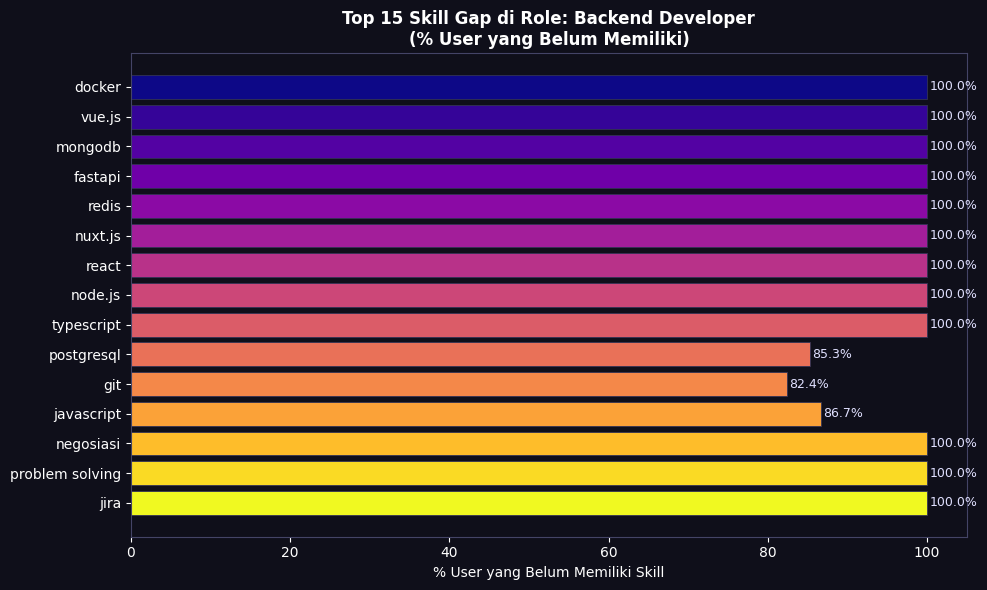

In [27]:
# SEL KODE 1: Bar Chart - Top 15 Skill Gap
top_gap = gap_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a') # Memastikan background di dalam plot juga gelap

# Bar — % user yang belum punya skill
cmap2 = plt.cm.get_cmap('plasma', 15)
col2 = [cmap2(i/15) for i in range(15)]

bars1 = ax.barh(top_gap['skill'], top_gap['pct_users_missing'],
                color=col2, edgecolor='#333355', linewidth=0.6)

ax.set_title(f'Top 15 Skill Gap di Role: {target_role.title()}\n(% User yang Belum Memiliki)',
             fontsize=12, fontweight='bold', color='white')
ax.set_xlabel('% User yang Belum Memiliki Skill', color='white')
ax.invert_yaxis()

# Atur warna text sumbu agar terlihat di background gelap
ax.tick_params(colors='white')

for bar, val in zip(bars1, top_gap['pct_users_missing']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#e0e0ff')

plt.tight_layout()
plt.savefig('plot_bq2_skill_gap_bar.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

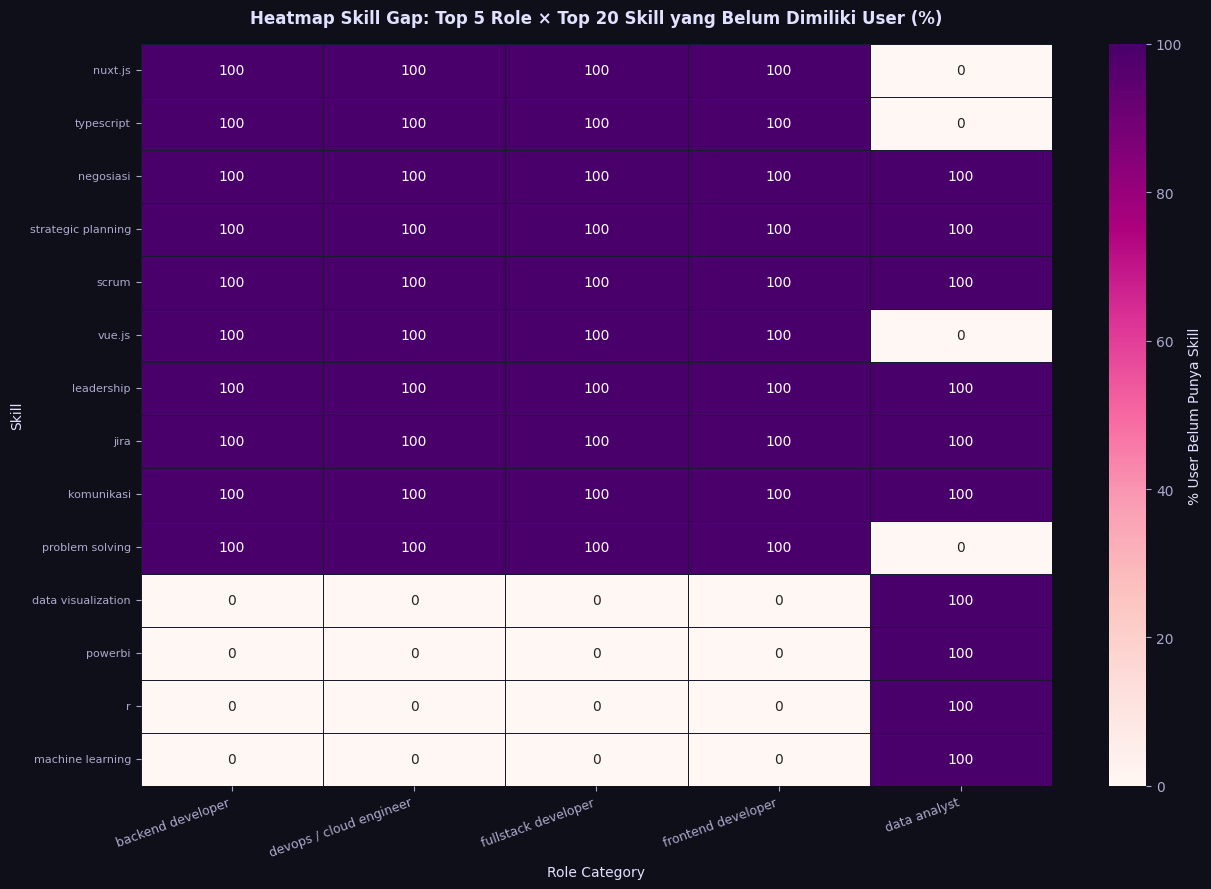

In [ ]:
# Heatmap skill gap per top-5 role
top5_roles = avg_match.head(5)['role_category'].tolist()

heat_data = {}
for role in top5_roles:
    pool = role_skill_pool[role]
    gap_c = Counter()
    for _, user in cv.iterrows():
        uset = user_skills_set(user)
        gap_c.update(pool - uset)
    top10 = [s for s,_ in gap_c.most_common(10)]
    heat_data[role] = {s: gap_c[s]/cv.shape[0]*100 for s in top10}

all_skills_heat = []
for skills in heat_data.values():
    all_skills_heat.extend(skills.keys())
all_skills_heat = list(dict.fromkeys(all_skills_heat))[:20]

heat_matrix = pd.DataFrame(
    {role: [heat_data[role].get(s, 0) for s in all_skills_heat] for role in top5_roles},
    index=all_skills_heat)

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#0f0f1a')
sns.heatmap(heat_matrix, ax=ax, cmap='RdPu', annot=True, fmt='.0f',
            linewidths=0.4, linecolor='#1a1a2e',
            cbar_kws={'label': '% User Belum Punya Skill'})
ax.set_title('Heatmap Skill Gap: Top 5 Role × Top 20 Skill yang Belum Dimiliki User (%)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Role Category'); ax.set_ylabel('Skill')
plt.xticks(rotation=20, ha='right', fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('plot_bq2_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

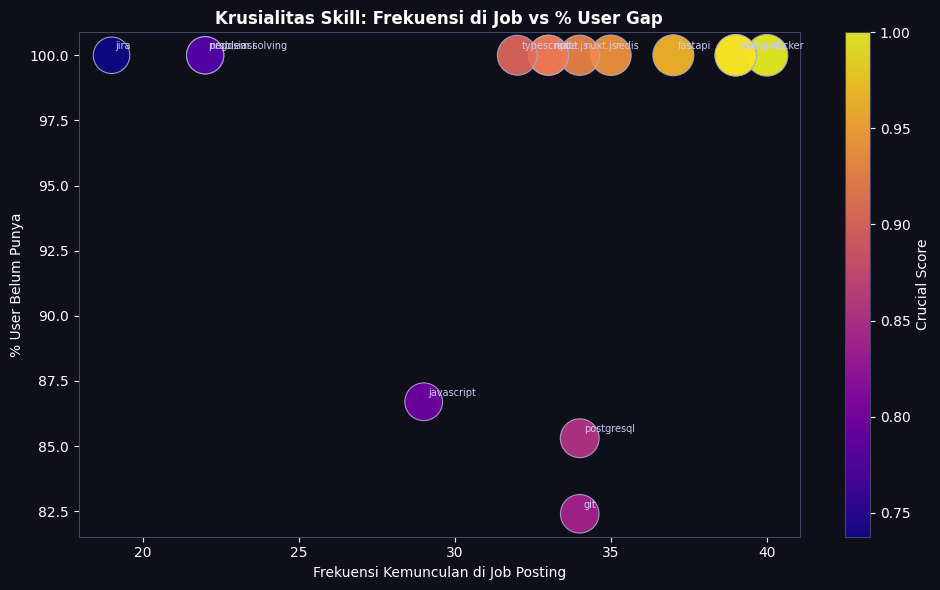

In [28]:
# SEL KODE 2: Scatter Plot - Krusialitas Skill
# Pastikan variabel top_gap sudah di-run/tersedia dari sel sebelumnya

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

# Scatter — gap popularity vs job frequency (krusialitas)
sc = ax.scatter(top_gap['job_freq'], top_gap['pct_users_missing'],
                s=top_gap['crucial_score']*800+100,
                c=top_gap['crucial_score'], cmap='plasma',
                edgecolors='#aaaacc', linewidths=0.8, alpha=0.9)

for _, row in top_gap.iterrows():
    ax.annotate(row['skill'], (row['job_freq'], row['pct_users_missing']),
                fontsize=7, ha='left', va='bottom', color='#ccccee',
                xytext=(3, 3), textcoords='offset points')

ax.set_title('Krusialitas Skill: Frekuensi di Job vs % User Gap',
             fontsize=12, fontweight='bold', color='white')
ax.set_xlabel('Frekuensi Kemunculan di Job Posting', color='white')
ax.set_ylabel('% User Belum Punya', color='white')

# Atur warna text sumbu
ax.tick_params(colors='white')

# Menampilkan colorbar dan mengatur warna teksnya menjadi putih
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Crucial Score', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.tight_layout()
plt.savefig('plot_bq2_skill_gap_scatter.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [29]:
print("=" * 65)
print("JAWABAN BUSINESS QUESTION 2")
print(f"Target Role: {target_role.upper()}")
print("=" * 65)
print("\nTop 10 Skill Krusial yang BELUM dimiliki mayoritas user:")
print(f"{'Rank':<5} {'Skill':<30} {'% User Gap':>10}  {'Job Freq':>8}  {'Crucial Score':>13}")
print("-" * 70)
for i, row in gap_df.head(10).iterrows():
    print(f"{i+1:<5} {row['skill']:<30} {row['pct_users_missing']:>9.1f}%  {row['job_freq']:>8}  {row['crucial_score']:>13.4f}")
print("=" * 65)

JAWABAN BUSINESS QUESTION 2
Target Role: BACKEND DEVELOPER

Top 10 Skill Krusial yang BELUM dimiliki mayoritas user:
Rank  Skill                          % User Gap  Job Freq  Crucial Score
----------------------------------------------------------------------
1     docker                             100.0%        40         1.0000
2     vue.js                             100.0%        39         0.9875
3     mongodb                            100.0%        39         0.9875
4     fastapi                            100.0%        37         0.9625
5     redis                              100.0%        35         0.9375
6     nuxt.js                            100.0%        34         0.9250
7     react                              100.0%        33         0.9125
8     node.js                            100.0%        33         0.9125
9     typescript                         100.0%        32         0.9000
10    postgresql                          85.3%        34         0.8515


## **Business Question 3**
Apa saja 3–5 pekerjaan teratas yang paling cocok dengan users beserta persentase kecocokannya?

**Pendekatan:**
- Hitung match score tiap user ke tiap `role_category`  
- Ambil top-5 role per user → agregat ranking secara keseluruhan  
- Sajikan visualisasi ranking + distribusi persentase kecocokan


In [30]:
# ── Top-5 role per user ───────────────────────────────────────────────────────
top5_per_user = (match_df.sort_values(['user_id','match_score'], ascending=[True,False])
                  .groupby('user_id')
                  .head(5)
                  .assign(rank=lambda d: d.groupby('user_id').cumcount() + 1))

print("Contoh top-5 role untuk 2 user pertama:")
display(top5_per_user.head(10))

Contoh top-5 role untuk 2 user pertama:


,user_id,role,match_score,matched_skills,pool_size,rank
7551,0076187a-15b5-4ebf-bb9e-c1316d7457e5,data analyst,0.150000,3,20,1
7552,0076187a-15b5-4ebf-bb9e-c1316d7457e5,data scientist / ml engineer,0.150000,3,20,2
7558,0076187a-15b5-4ebf-bb9e-c1316d7457e5,researcher,0.150000,3,20,3
7550,0076187a-15b5-4ebf-bb9e-c1316d7457e5,backend developer,0.045455,1,22,4
7553,0076187a-15b5-4ebf-bb9e-c1316d7457e5,devops / cloud engineer,0.045455,1,22,5
4390,0141e3fe-b2b2-4f9a-80c9-dd920bad147b,backend developer,0.000000,0,22,1
4391,0141e3fe-b2b2-4f9a-80c9-dd920bad147b,data analyst,0.000000,0,20,2
4392,0141e3fe-b2b2-4f9a-80c9-dd920bad147b,data scientist / ml engineer,0.000000,0,20,3
4393,0141e3fe-b2b2-4f9a-80c9-dd920bad147b,devops / cloud engineer,0.000000,0,22,4
4394,0141e3fe-b2b2-4f9a-80c9-dd920bad147b,frontend developer,0.000000,0,22,5


In [31]:
# ── Frekuensi role masuk sebagai top-1 s.d. top-5 ────────────────────────────
rank_counts = (top5_per_user.groupby(['role','rank'])['user_id']
               .count()
               .unstack(fill_value=0)
               .rename(columns={i: f'rank_{i}' for i in range(1,6)}))

# Weighted rank score (rank-1 = bobot 5, rank-5 = bobot 1)
weights = {f'rank_{i}': 6-i for i in range(1,6)}
rank_counts['weighted_score'] = sum(rank_counts.get(col,0) * w for col, w in weights.items())
rank_counts = rank_counts.sort_values('weighted_score', ascending=False)

print("Frekuensi & weighted score per role:")
display(rank_counts)

Frekuensi & weighted score per role:


rank,rank_1,rank_2,rank_3,rank_4,rank_5,weighted_score
role,,,,,,
backend developer,579,0,0,267,0,3429
data analyst,267,327,0,154,252,3203
data scientist / ml engineer,0,267,327,0,154,2203
devops / cloud engineer,0,252,0,327,267,1929
frontend developer,0,0,252,0,327,1083
researcher,0,0,267,0,0,801
hr / recruiter,154,0,0,0,0,770
product manager,0,154,0,0,0,616
fullstack developer,0,0,0,252,0,504


In [32]:
# ── Rata-rata match score top-1 role per user ─────────────────────────────────
top1_per_user = top5_per_user[top5_per_user['rank'] == 1]
top1_avg = (top1_per_user.groupby('role')['match_score']
            .agg(['mean','median','count'])
            .round(4)
            .sort_values('mean', ascending=False)
            .reset_index())
top1_avg.columns = ['role_category','avg_match_top1','median_match_top1','user_count_top1']
top1_avg['avg_match_pct'] = (top1_avg['avg_match_top1']*100).round(2)

print("Rata-rata match score saat role menjadi #1 pilihan user:")
display(top1_avg)

Rata-rata match score saat role menjadi #1 pilihan user:


,role_category,avg_match_top1,median_match_top1,user_count_top1,avg_match_pct
0,hr / recruiter,0.1111,0.1111,154,11.11
1,data analyst,0.0895,0.1000,267,8.95
2,backend developer,0.0466,0.0000,579,4.66


ValueError: List of violinplot statistics and `positions` values must have the same length

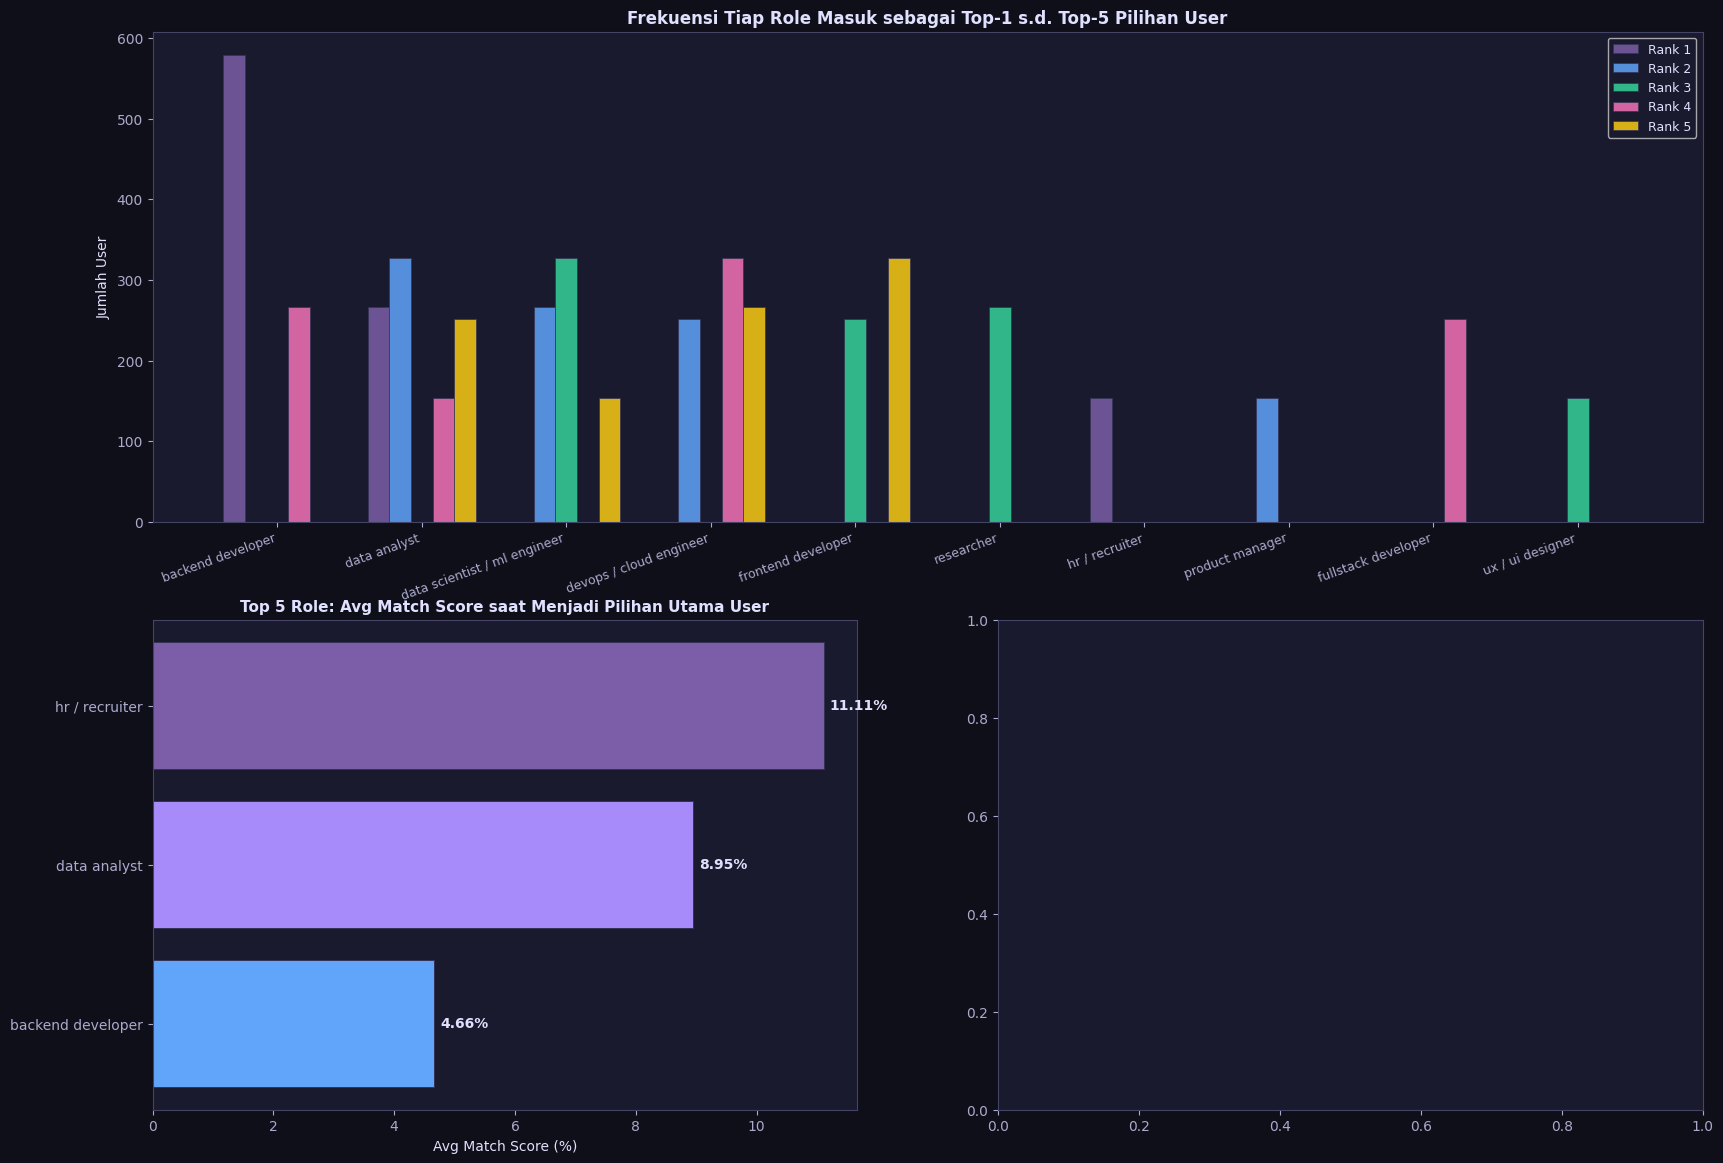

In [33]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0f0f1a')

# ── Sub-plot 1: Grouped bar — frekuensi per rank ─────────────────────────────
ax1 = fig.add_subplot(2, 2, (1,2))
rank_cols = [c for c in rank_counts.columns if c.startswith('rank_')]
x = np.arange(len(rank_counts))
width = 0.15
rank_colors = ['#7b5ea7','#60a5fa','#34d399','#f472b6','#facc15']
for i, (col, color) in enumerate(zip(rank_cols, rank_colors)):
    ax1.bar(x + i*width, rank_counts[col], width, label=col.replace('_',' ').title(),
            color=color, edgecolor='#333355', linewidth=0.6, alpha=0.85)
ax1.set_xticks(x + width*2)
ax1.set_xticklabels(rank_counts.index, rotation=20, ha='right', fontsize=9)
ax1.set_title('Frekuensi Tiap Role Masuk sebagai Top-1 s.d. Top-5 Pilihan User',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah User'); ax1.legend(fontsize=9, loc='upper right')

# ── Sub-plot 2: Horizontal bar — avg match score top-1 ───────────────────────
ax2 = fig.add_subplot(2, 2, 3)
top5_display = top1_avg.head(5)
c_bar = [PALETTE[i] for i in range(5)]
hbars = ax2.barh(top5_display['role_category'], top5_display['avg_match_pct'],
                 color=c_bar, edgecolor='#333355', linewidth=0.7)
ax2.set_title('Top 5 Role: Avg Match Score saat Menjadi Pilihan Utama User',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Avg Match Score (%)')
ax2.invert_yaxis()
for bar, val in zip(hbars, top5_display['avg_match_pct']):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10, fontweight='bold', color='#e0e0ff')

# ── Sub-plot 3: Violin — distribusi match score top-5 role ───────────────────
ax3 = fig.add_subplot(2, 2, 4)
top5_role_names = top1_avg.head(5)['role_category'].tolist()
violin_data = [match_df[match_df['role']==r]['match_score']*100 for r in top5_role_names]
parts = ax3.violinplot(violin_data, positions=range(1, 6), showmedians=True)
for i, (pc, color) in enumerate(zip(parts['bodies'], c_bar)):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts['cmedians'].set_color('#facc15'); parts['cmedians'].set_linewidth(2)
ax3.set_xticks(range(1, 6))
ax3.set_xticklabels([r.replace(' / ','/\n') for r in top5_role_names], fontsize=8)
ax3.set_title('Distribusi Match Score — Top 5 Role (Violin Plot)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Match Score (%)')

plt.suptitle('Business Question 3 — Pekerjaan Paling Cocok dengan User',
             fontsize=15, fontweight='bold', y=1.02, color='#a78bfa')
plt.tight_layout()
plt.savefig('plot_bq3_top5_jobs.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

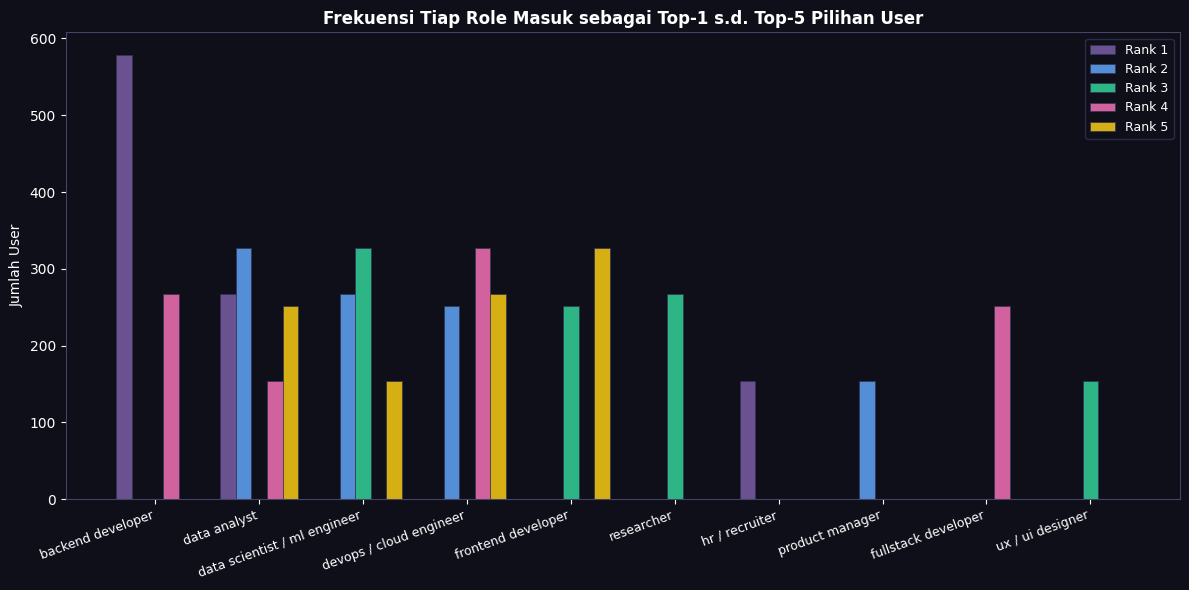

In [35]:
# SEL KODE 1: Frekuensi Tiap Role (Top-1 s.d. Top-5)
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

rank_cols = [c for c in rank_counts.columns if c.startswith('rank_')]
x = np.arange(len(rank_counts))
width = 0.15
rank_colors = ['#7b5ea7','#60a5fa','#34d399','#f472b6','#facc15']

for i, (col, color) in enumerate(zip(rank_cols, rank_colors)):
    ax.bar(x + i*width, rank_counts[col], width, label=col.replace('_',' ').title(),
           color=color, edgecolor='#333355', linewidth=0.6, alpha=0.85)

ax.set_xticks(x + width*2)
ax.set_xticklabels(rank_counts.index, rotation=20, ha='right', fontsize=9, color='white')
ax.tick_params(colors='white')

ax.set_title('Frekuensi Tiap Role Masuk sebagai Top-1 s.d. Top-5 Pilihan User',
             fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Jumlah User', color='white')

# Menyesuaikan warna legend untuk dark mode
legend = ax.legend(fontsize=9, loc='upper right', facecolor='#0f0f1a', edgecolor='#333355')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig('plot_bq3_rank_freq.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

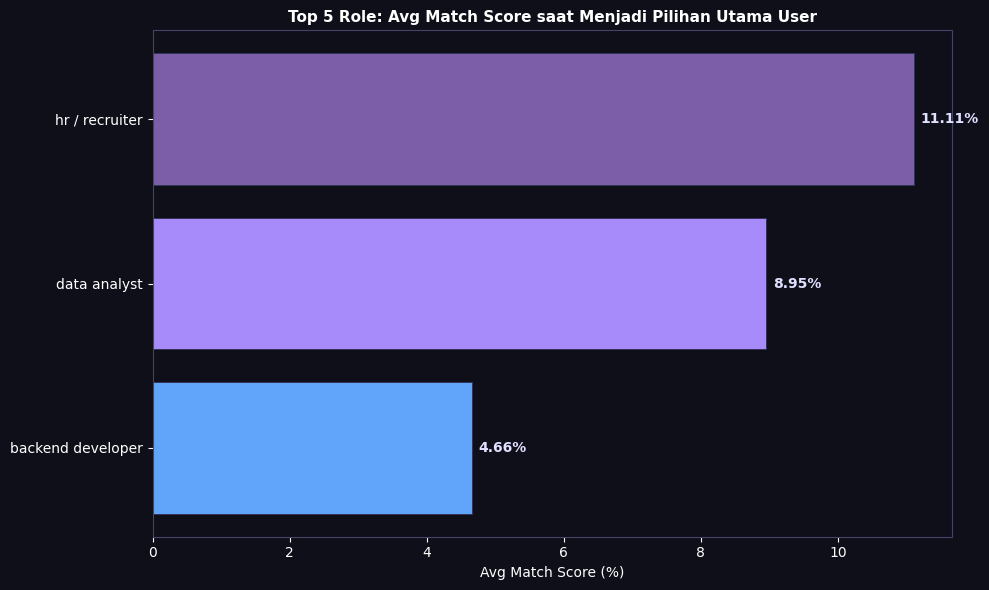

In [36]:
# SEL KODE 2: Avg Match Score Top-1
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

top5_display = top1_avg.head(5)

# Catatan: Pastikan variabel PALETTE sudah didefinisikan sebelumnya di notebook Anda.
# Jika belum ada, Anda bisa menggantinya misal dengan: c_bar = ['#7b5ea7','#60a5fa','#34d399','#f472b6','#facc15']
c_bar = [PALETTE[i] for i in range(5)]

hbars = ax.barh(top5_display['role_category'], top5_display['avg_match_pct'],
                color=c_bar, edgecolor='#333355', linewidth=0.7)

ax.set_title('Top 5 Role: Avg Match Score saat Menjadi Pilihan Utama User',
             fontsize=11, fontweight='bold', color='white')
ax.set_xlabel('Avg Match Score (%)', color='white')
ax.invert_yaxis()

# Set warna tick agar putih
ax.tick_params(colors='white')

for bar, val in zip(hbars, top5_display['avg_match_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10, fontweight='bold', color='#e0e0ff')

plt.tight_layout()
plt.savefig('plot_bq3_avg_match.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

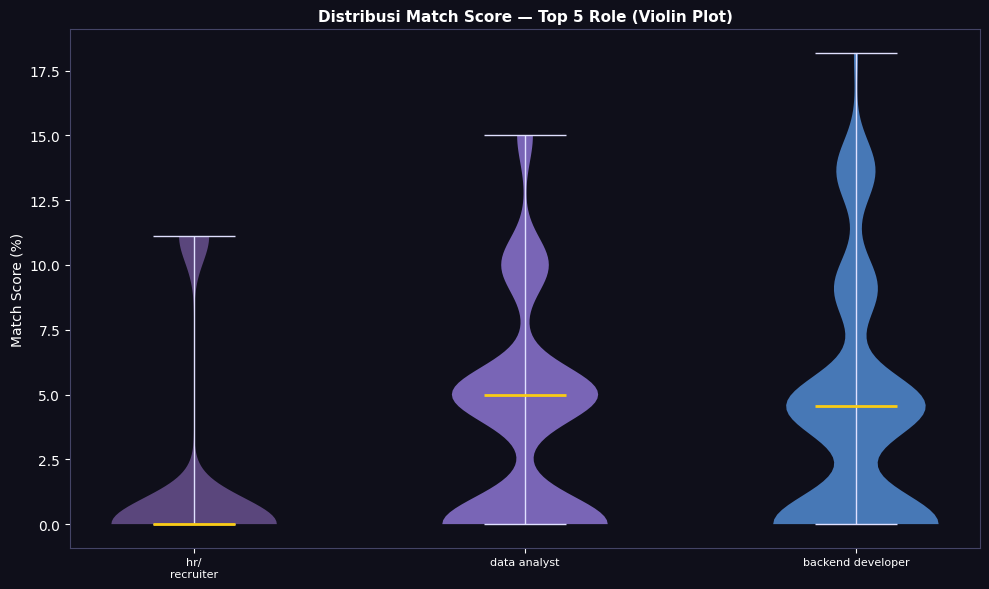

In [38]:
# SEL KODE 3: Distribusi Match Score (Violin Plot)
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

# Ambil nama role
top5_role_names = top1_avg.head(5)['role_category'].tolist()

# Ambil datanya dan pastikan kita hanya menyimpan data yang tidak kosong
violin_data = []
valid_role_names = []
for r in top5_role_names:
    data = match_df[match_df['role']==r]['match_score'] * 100
    if not data.empty:
        violin_data.append(data)
        valid_role_names.append(r)

# Hitung jumlah aktual data yang akan diplot
num_violins = len(violin_data)

# Jika ternyata ada datanya, baru kita plot
if num_violins > 0:
    # Gunakan range(1, num_violins + 1) agar panjangnya presisi sama
    parts = ax.violinplot(violin_data, positions=range(1, num_violins + 1), showmedians=True)

    # Mewarnai setiap bagian biola
    for i, (pc, color) in enumerate(zip(parts['bodies'], c_bar[:num_violins])):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    parts['cmedians'].set_color('#facc15')
    parts['cmedians'].set_linewidth(2)

    # Menyesuaikan garis pembatas violin agar lebih terang di dark mode
    for partname in ('cbars', 'cmins', 'cmaxes'):
        parts[partname].set_color('#e0e0ff')
        parts[partname].set_linewidth(1)

    # Set xticks sejumlah data yang valid
    ax.set_xticks(range(1, num_violins + 1))
    ax.set_xticklabels([r.replace(' / ','/\n') for r in valid_role_names], fontsize=8, color='white')

ax.tick_params(colors='white')
ax.set_title('Distribusi Match Score — Top 5 Role (Violin Plot)',
             fontsize=11, fontweight='bold', color='white')
ax.set_ylabel('Match Score (%)', color='white')

plt.tight_layout()
plt.savefig('plot_bq3_violin_dist.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

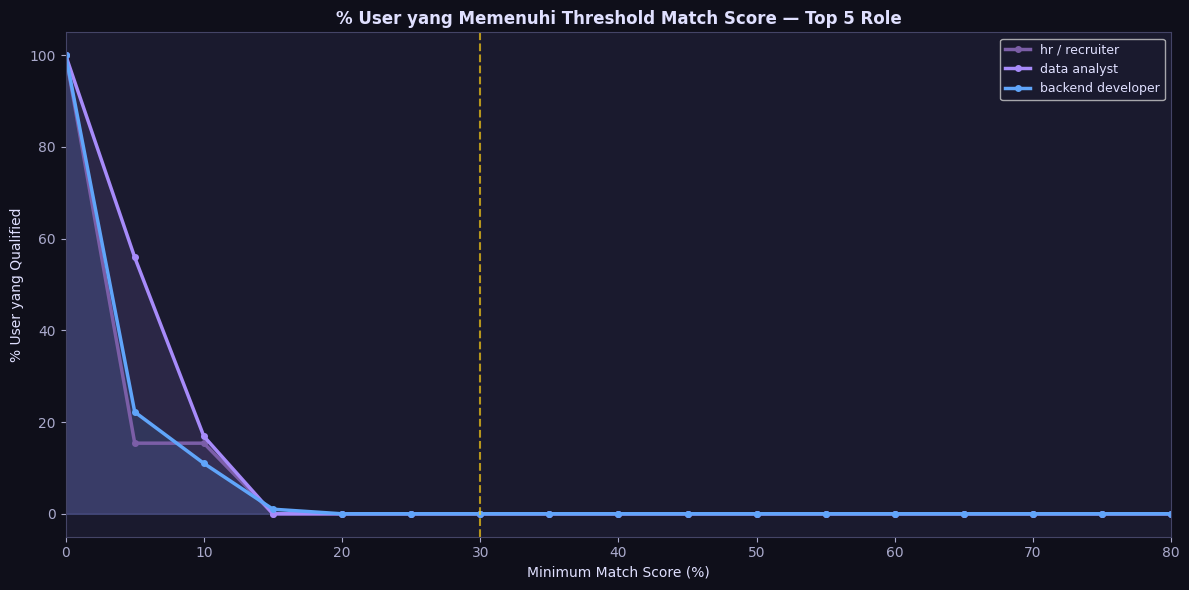

In [39]:
# ── Stacked area — akumulasi user yang tertampung per match threshold ─────────
thresholds = np.arange(0, 0.81, 0.05)
stack_data = {}
for role in top5_role_names:
    scores = match_df[match_df['role']==role]['match_score'].values
    stack_data[role] = [(scores >= t).sum() / cv.shape[0] * 100 for t in thresholds]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f1a')
for i, (role, vals) in enumerate(stack_data.items()):
    ax.plot(thresholds*100, vals, color=PALETTE[i], linewidth=2.5,
            label=role, marker='o', markersize=4)
    ax.fill_between(thresholds*100, vals, alpha=0.12, color=PALETTE[i])
ax.set_title('% User yang Memenuhi Threshold Match Score — Top 5 Role',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Minimum Match Score (%)'); ax.set_ylabel('% User yang Qualified')
ax.legend(fontsize=9, loc='upper right'); ax.set_xlim(0, 80)
ax.axvline(30, color='#facc15', linestyle='--', linewidth=1.5, alpha=0.7, label='Threshold 30%')
plt.tight_layout()
plt.savefig('plot_bq3_threshold_curve.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [40]:
# ── Ringkasan final BQ3 ───────────────────────────────────────────────────────
print("=" * 70)
print("JAWABAN BUSINESS QUESTION 3")
print("   Top 5 Pekerjaan Paling Cocok dengan Users di Pasar Lokal")
print("=" * 70)
print(f"{'Rank':<5} {'Role Category':<35} {'Avg Match %':>11}  {'Median Match %':>14}  {'# Users (top-1)':>15}")
print("-" * 80)
for rank, (_, row) in enumerate(top1_avg.head(5).iterrows(), 1):
    stars = '⭐' * (6 - rank)
    print(f"{rank:<5} {row['role_category']:<35} {row['avg_match_pct']:>10.2f}%  "
          f"{row['median_match_top1']*100:>13.2f}%  {int(row['user_count_top1']):>15,}   {stars}")
print("=" * 70)
print()
print("Metode: Jaccard-style skill matching (user skills ∩ job pool) / |job pool|")
print("Score 100% = user memiliki semua skill yang dibutuhkan role tersebut")

JAWABAN BUSINESS QUESTION 3
   Top 5 Pekerjaan Paling Cocok dengan Users di Pasar Lokal
Rank  Role Category                       Avg Match %  Median Match %  # Users (top-1)
--------------------------------------------------------------------------------
1     hr / recruiter                           11.11%          11.11%              154   ⭐⭐⭐⭐⭐
2     data analyst                              8.95%          10.00%              267   ⭐⭐⭐⭐
3     backend developer                         4.66%           0.00%              579   ⭐⭐⭐

Metode: Jaccard-style skill matching (user skills ∩ job pool) / |job pool|
Score 100% = user memiliki semua skill yang dibutuhkan role tersebut


---
## 📋 Ringkasan Eksekutif

| # | Business Question | Temuan Utama |
|---|---|---|
| 1 | Role dengan kecocokan tertinggi | Lihat output BQ1 — role dengan avg match score tertinggi |
| 2 | Skill krusial yang belum dimiliki | Top skill gap berdasarkan frekuensi job posting & % user yang belum memiliki |
| 3 | Top 3–5 pekerjaan paling cocok | Lihat tabel BQ3 dengan persentase kecocokan per role |

**Metodologi Singkat:**
- **Match Score** = |Skills User ∩ Skill Pool Role| / |Skill Pool Role| × 100%
- **Skill Gap** = Skills yang ada di pool role target tapi tidak dimiliki user (dibobot dengan frekuensi kemunculan di job posting)
- **Crucial Score** = 0.5 × (% user gap) + 0.5 × (normalized job freq)
